# PREPROCESSING - PlantVillage (PyTorch)

Notebook này nối tiếp trực tiếp từ `01_eda.ipynb`.

Từ EDA:
- Dataset đã có sẵn hai split `train` và `val`.
- Tỉ lệ validation giữa các class khá đồng đều, khoảng 20%.
- Dữ liệu mất cân bằng đáng kể; EDA ghi nhận tỉ lệ class lớn nhất / nhỏ nhất khoảng `36.23`.
- EDA đã kiểm tra exact duplicate bằng SHA-256 giữa `train` và `val`.
- EDA cũng kiểm tra near-duplicate bằng pHash.

Vì vậy preprocessing sẽ:
1. Đọc `DATA_DIR` từ `.env`.
2. Giữ nguyên split `train/val`, không chia lại.
3. Loại exact duplicate ở validation nếu cùng ảnh đã xuất hiện trong train.
4. Không tự động xóa near-duplicate.
5. Chuẩn hóa ảnh về RGB.
6. Resize về `224 x 224`.
7. Chuyển ảnh thành tensor và scale pixel về `[0, 1]`.
8. Data augmentation chỉ cho train.
9. Tạo `Dataset` và `DataLoader` bằng PyTorch.
10. Tính class weight để hỗ trợ xử lý class imbalance khi train.
11. Lưu metadata sạch và mapping label để dùng lại ở notebook model.


# I. IMPORT VÀ CẤU HÌNH


In [25]:
from pathlib import Path
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from dotenv import load_dotenv

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)


PyTorch version: 2.14.0+cpu
Device: cpu


In [8]:
PROJECT_ROOT = Path.cwd()

# Nếu notebook đang chạy từ thư mục notebooks/
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ENV_PATH = PROJECT_ROOT / ".env"

load_dotenv(ENV_PATH, override=True)

data_dir_value = os.getenv("DATA_DIR")

if not data_dir_value:
    raise ValueError(
        f"Không tìm thấy DATA_DIR trong {ENV_PATH}. "
        "Ví dụ trong .env: DATA_DIR=D:/.../PlantVillage"
    )

DATA_DIR = Path(data_dir_value)
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"

METADATA_DIR = PROJECT_ROOT / "data" / "metadata"
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ENV_PATH:", ENV_PATH)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists:", DATA_DIR.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("VAL_DIR exists:", VAL_DIR.exists())

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Không tìm thấy DATA_DIR: {DATA_DIR}")

if not TRAIN_DIR.exists() or not VAL_DIR.exists():
    raise FileNotFoundError(
        "DATA_DIR phải chứa trực tiếp hai thư mục train/ và val/."
    )


PROJECT_ROOT: d:\Plant_disease\plant-disease-classification
ENV_PATH: d:\Plant_disease\plant-disease-classification\.env
DATA_DIR: D:\Plant_disease\PlantVillage
DATA_DIR exists: True
TRAIN_DIR exists: True
VAL_DIR exists: True


In [26]:
metadata_path = METADATA_DIR / "metadata.csv"

if not metadata_path.exists():
    raise FileNotFoundError(
        f"Không tìm thấy {metadata_path}. "
        "Hãy chạy phần tạo metadata trong 01_eda.ipynb trước."
    )

df = pd.read_csv(metadata_path)

print("Metadata shape:", df.shape)
display(df.head())


Metadata shape: (54305, 6)


,relative_path,split,class_name,plant,condition,is_healthy
0,train\Apple___Apple_scab\01a66316-0e98-4d3b-a5...,train,Apple___Apple_scab,Apple,Apple_scab,False
1,train\Apple___Apple_scab\01f3deaa-6143-4b6c-9c...,train,Apple___Apple_scab,Apple,Apple_scab,False
2,train\Apple___Apple_scab\0208f4eb-45a4-4399-90...,train,Apple___Apple_scab,Apple,Apple_scab,False
3,train\Apple___Apple_scab\023123cb-7b69-4c9f-a5...,train,Apple___Apple_scab,Apple,Apple_scab,False
4,train\Apple___Apple_scab\0261a6e4-21f8-481a-88...,train,Apple___Apple_scab,Apple,Apple_scab,False


In [27]:
required_columns = {
    "relative_path",
    "split",
    "class_name",
}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"metadata.csv đang thiếu các cột: {missing_columns}"
    )

print("Split:")
print(df["split"].value_counts())

print("\nNumber of classes:", df["class_name"].nunique())
print("Duplicated relative_path:", df["relative_path"].duplicated().sum())


Split:
split
train    43444
val      10861
Name: count, dtype: int64

Number of classes: 38
Duplicated relative_path: 0


# III. XỬ LÝ EXACT DUPLICATE GIỮA TRAIN VÀ VAL


EDA đã tạo `duplicate_images.csv` bằng SHA-256.

Ở preprocessing:
- Nếu cùng SHA-256 xuất hiện ở cả `train` và `val`, giữ bản ở `train`.
- Loại bản ở `val` khỏi metadata dùng để train/validation.
- Không xóa file ảnh vật lý.
- Không tự động xóa near-duplicate vì pHash gần nhau không đảm bảo hai ảnh thật sự là cùng một mẫu.


In [28]:
duplicate_path = METADATA_DIR / "duplicate_images.csv"

clean_df = df.copy()
removed_leakage_paths = []

if duplicate_path.exists():
    duplicate_df = pd.read_csv(duplicate_path)

    needed_columns = {"relative_path", "split", "sha256"}

    if needed_columns.issubset(duplicate_df.columns):
        cross_split_hashes = (
            duplicate_df.groupby("sha256")["split"]
            .nunique()
        )

        cross_split_hashes = cross_split_hashes[
            cross_split_hashes > 1
        ].index

        val_leakage = duplicate_df[
            duplicate_df["sha256"].isin(cross_split_hashes)
            & (duplicate_df["split"] == "val")
        ]

        removed_leakage_paths = (
            val_leakage["relative_path"]
            .drop_duplicates()
            .tolist()
        )

        clean_df = clean_df[
            ~clean_df["relative_path"].isin(removed_leakage_paths)
        ].copy()

        print("Cross-split duplicate hash groups:", len(cross_split_hashes))
        print("Validation images removed from metadata:", len(removed_leakage_paths))

    else:
        print(
            "duplicate_images.csv không có đủ cột cần thiết:",
            needed_columns
        )
else:
    print(
        "Không tìm thấy duplicate_images.csv. "
        "Notebook tiếp tục nhưng chưa loại exact duplicate train/val."
    )

print("Before cleaning:", len(df))
print("After cleaning:", len(clean_df))


Cross-split duplicate hash groups: 10
Validation images removed from metadata: 10
Before cleaning: 54305
After cleaning: 54295


# IV. KIỂM TRA FILE ẢNH


In [10]:
required_columns = {
    "relative_path",
    "split",
    "class_name",
}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"metadata.csv đang thiếu các cột: {missing_columns}"
    )

print("Split:")
print(df["split"].value_counts())

print("\nNumber of classes:", df["class_name"].nunique())
print("Duplicated relative_path:", df["relative_path"].duplicated().sum())


Split:
split
train    43444
val      10861
Name: count, dtype: int64

Number of classes: 38
Duplicated relative_path: 0


In [11]:
duplicate_path = METADATA_DIR / "duplicate_images.csv"

clean_df = df.copy()
removed_leakage_paths = []

if duplicate_path.exists():
    duplicate_df = pd.read_csv(duplicate_path)

    needed_columns = {"relative_path", "split", "sha256"}

    if needed_columns.issubset(duplicate_df.columns):
        cross_split_hashes = (
            duplicate_df.groupby("sha256")["split"]
            .nunique()
        )

        cross_split_hashes = cross_split_hashes[
            cross_split_hashes > 1
        ].index

        val_leakage = duplicate_df[
            duplicate_df["sha256"].isin(cross_split_hashes)
            & (duplicate_df["split"] == "val")
        ]

        removed_leakage_paths = (
            val_leakage["relative_path"]
            .drop_duplicates()
            .tolist()
        )

        clean_df = clean_df[
            ~clean_df["relative_path"].isin(removed_leakage_paths)
        ].copy()

        print("Cross-split duplicate hash groups:", len(cross_split_hashes))
        print("Validation images removed from metadata:", len(removed_leakage_paths))

    else:
        print(
            "duplicate_images.csv không có đủ cột cần thiết:",
            needed_columns
        )
else:
    print(
        "Không tìm thấy duplicate_images.csv. "
        "Notebook tiếp tục nhưng chưa loại exact duplicate train/val."
    )

print("Before cleaning:", len(df))
print("After cleaning:", len(clean_df))


Cross-split duplicate hash groups: 10
Validation images removed from metadata: 10
Before cleaning: 54305
After cleaning: 54295


In [30]:
def image_exists(relative_path):
    return (DATA_DIR / relative_path).is_file()

exists_mask = clean_df["relative_path"].map(image_exists)

print("Existing images:", int(exists_mask.sum()))
print("Missing images:", int((~exists_mask).sum()))

if (~exists_mask).any():
    display(
        clean_df.loc[
            ~exists_mask,
            ["relative_path", "split", "class_name"]
        ].head()
    )

clean_df = clean_df.loc[exists_mask].reset_index(drop=True)


Existing images: 54295
Missing images: 0


# V. MÃ HÓA LABEL


In [29]:
class_names = sorted(clean_df["class_name"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

clean_df["label"] = (
    clean_df["class_name"]
    .map(class_to_idx)
    .astype("int64")
)

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)

for class_name in class_names[:5]:
    print(
        class_to_idx[class_name],
        "->",
        class_name
    )


Number of classes: 38
0 -> Apple___Apple_scab
1 -> Apple___Black_rot
2 -> Apple___Cedar_apple_rust
3 -> Apple___healthy
4 -> Blueberry___healthy


In [31]:
train_df = (
    clean_df[clean_df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    clean_df[clean_df["split"] == "val"]
    .copy()
    .reset_index(drop=True)
)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Total images:", len(clean_df))

train_classes = set(train_df["class_name"])
val_classes = set(val_df["class_name"])

print("\nClasses only in train:")
print(train_classes - val_classes)

print("\nClasses only in val:")
print(val_classes - train_classes)


Train images: 43444
Validation images: 10851
Total images: 54295

Classes only in train:
set()

Classes only in val:
set()


# VI. IMAGE TRANSFORMS


### Train transform

Ảnh train sẽ được:
- chuyển về RGB trong `Dataset`;
- resize về `224 x 224`;
- lật ngang ngẫu nhiên;
- xoay nhẹ;
- thay đổi contrast/brightness nhẹ;
- chuyển sang tensor.

`transforms.ToTensor()` tự chuyển pixel từ `[0,255]` sang `[0,1]`.

### Validation transform

Validation chỉ:
- RGB;
- resize;
- ToTensor.

Không augmentation validation để việc đánh giá ổn định và công bằng.


In [32]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

print(train_transform)
print()
print(val_transform)


Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=None, hue=None)
    ToTensor()
)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


# VII. CUSTOM DATASET


In [33]:
class PlantVillageDataset(Dataset):
    def __init__(
        self,
        dataframe,
        data_dir,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = (
            self.data_dir
            / row["relative_path"]
        )

        with Image.open(image_path) as image:
            image = image.convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

        label = int(row["label"])

        return image, label


In [34]:
train_dataset = PlantVillageDataset(
    dataframe=train_df,
    data_dir=DATA_DIR,
    transform=train_transform
)

val_dataset = PlantVillageDataset(
    dataframe=val_df,
    data_dir=DATA_DIR,
    transform=val_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))


Train dataset: 43444
Validation dataset: 10851


# VIII. DATALOADER


In [35]:
# num_workers=0 là lựa chọn an toàn trên Windows/Jupyter.
# Khi pipeline đã chạy ổn, có thể thử tăng lên 2 hoặc 4 để đọc dữ liệu nhanh hơn.

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))


Train batches: 1358
Validation batches: 340


# IX. SANITY CHECK


In [36]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("Pixel min:", images.min().item())
print("Pixel max:", images.max().item())

print("Label min:", labels.min().item())
print("Label max:", labels.max().item())


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Pixel min: 0.0
Pixel max: 1.0
Label min: 0
Label max: 35


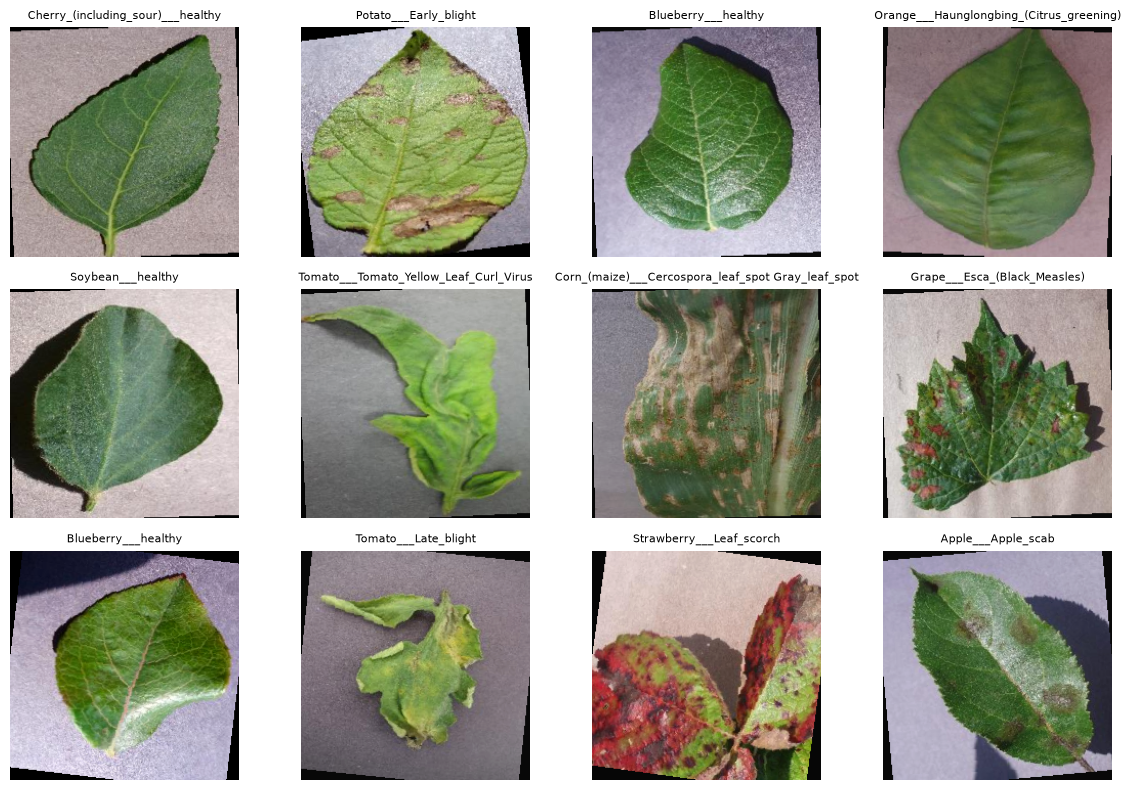

In [37]:
plt.figure(figsize=(12, 8))

n_show = min(12, len(images))

for i in range(n_show):
    image = images[i].permute(1, 2, 0).numpy()
    label = labels[i].item()

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(
        idx_to_class[label],
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


# X. CLASS WEIGHT


EDA ghi nhận class imbalance khá lớn, nên ta tính class weight từ tập train.

Các weight này có thể dùng trực tiếp với `CrossEntropyLoss`:

```python
criterion = torch.nn.CrossEntropyLoss(
    weight=class_weight_tensor.to(DEVICE)
)
```


In [38]:
classes = np.arange(NUM_CLASSES)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].to_numpy()
)

class_weight_tensor = torch.tensor(
    weights,
    dtype=torch.float32
)

class_weight_df = pd.DataFrame({
    "label": classes,
    "class_name": [
        idx_to_class[int(idx)]
        for idx in classes
    ],
    "class_weight": weights
}).sort_values(
    "class_weight",
    ascending=False
)

display(class_weight_df.head(10))


,label,class_name,class_weight
22,22,Potato___healthy,9.448456
2,2,Apple___Cedar_apple_rust,5.196651
17,17,Peach___healthy,3.969664
23,23,Raspberry___healthy,3.849371
36,36,Tomato___Tomato_mosaic_virus,3.823623
14,14,Grape___healthy,3.372458
27,27,Strawberry___healthy,3.140833
7,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,2.788447
1,1,Apple___Black_rot,2.304966
0,0,Apple___Apple_scab,2.268379


# XI. KIỂM TRA PHÂN BỐ SAU PREPROCESSING


In [39]:
distribution = (
    clean_df.groupby(
        ["class_name", "split"]
    )
    .size()
    .unstack(fill_value=0)
)

distribution["total"] = (
    distribution.sum(axis=1)
)

if "val" in distribution.columns:
    distribution["val_ratio"] = (
        distribution["val"]
        / distribution["total"]
    )

display(distribution)


split,train,val,total,val_ratio
class_name,,,,
Apple___Apple_scab,504,126,630,0.200000
Apple___Black_rot,496,125,621,0.201288
Apple___Cedar_apple_rust,220,55,275,0.200000
Apple___healthy,1316,324,1640,0.197561
Blueberry___healthy,1202,300,1502,0.199734
Cherry_(including_sour)___Powdery_mildew,842,210,1052,0.199620
Cherry_(including_sour)___healthy,684,170,854,0.199063
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,410,103,513,0.200780
Corn_(maize)___Common_rust_,953,239,1192,0.200503


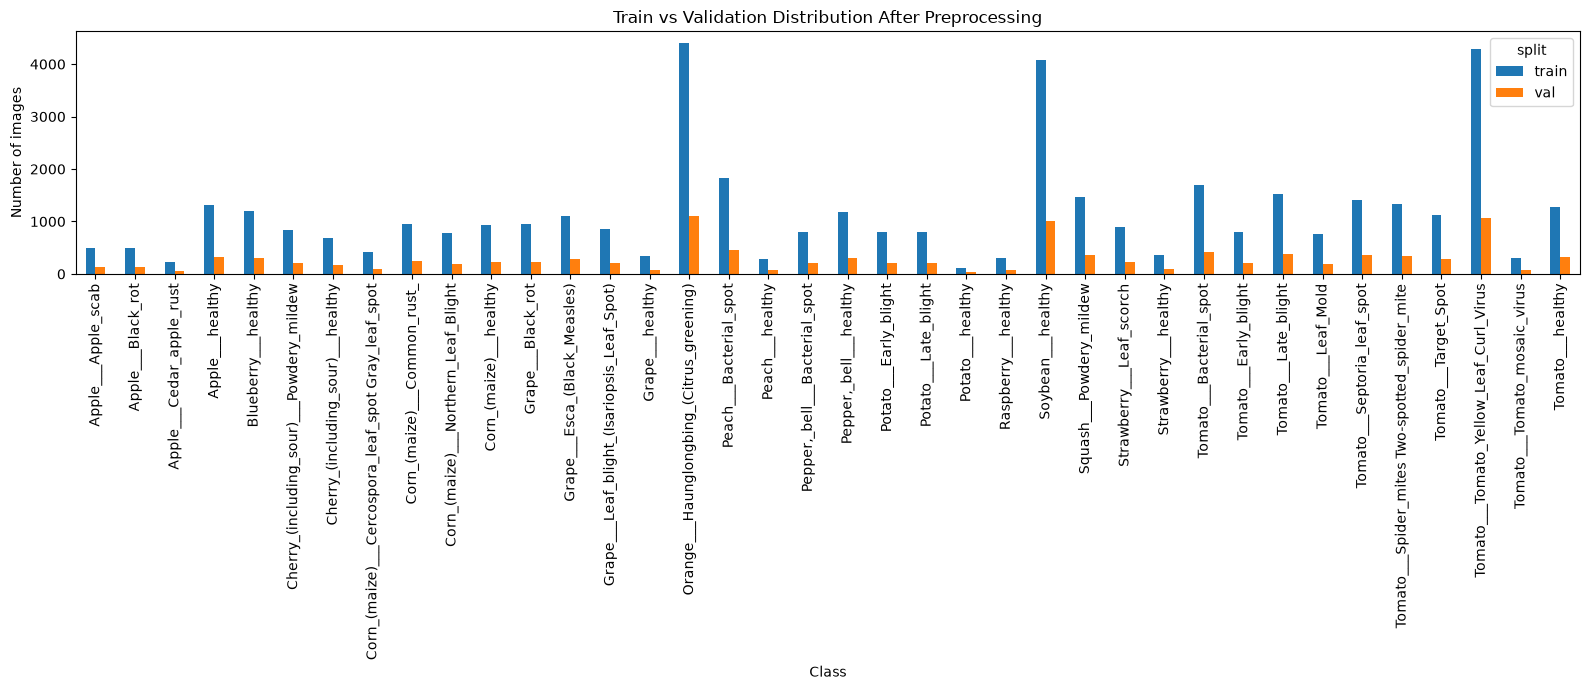

In [40]:
columns_to_plot = [
    column
    for column in ["train", "val"]
    if column in distribution.columns
]

ax = distribution[columns_to_plot].plot(
    kind="bar",
    figsize=(16, 7)
)

ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.set_title(
    "Train vs Validation Distribution After Preprocessing"
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# XII. LƯU KẾT QUẢ PREPROCESSING


In [41]:
clean_metadata_path = (
    METADATA_DIR
    / "clean_metadata.csv"
)

class_mapping_path = (
    METADATA_DIR
    / "class_to_idx.json"
)

class_weights_path = (
    METADATA_DIR
    / "class_weights.json"
)

config_path = (
    METADATA_DIR
    / "preprocessing_config.json"
)

clean_df.to_csv(
    clean_metadata_path,
    index=False
)

with open(
    class_mapping_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        class_to_idx,
        f,
        ensure_ascii=False,
        indent=2
    )

class_weights_dict = {
    str(int(idx)): float(weight)
    for idx, weight in zip(
        classes,
        weights
    )
}

with open(
    class_weights_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        class_weights_dict,
        f,
        ensure_ascii=False,
        indent=2
    )

preprocessing_config = {
    "framework": "PyTorch",
    "image_size": [IMG_SIZE, IMG_SIZE],
    "channels": 3,
    "pixel_range_after_to_tensor": [0.0, 1.0],
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "num_classes": NUM_CLASSES,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "removed_cross_split_exact_duplicates": len(
        removed_leakage_paths
    ),
    "train_augmentation": [
        "RandomHorizontalFlip(p=0.5)",
        "RandomRotation(10 degrees)",
        "ColorJitter(brightness=0.1, contrast=0.1)"
    ]
}

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        preprocessing_config,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Saved:")
print("-", clean_metadata_path)
print("-", class_mapping_path)
print("-", class_weights_path)
print("-", config_path)


Saved:
- d:\Plant_disease\plant-disease-classification\data\metadata\clean_metadata.csv
- d:\Plant_disease\plant-disease-classification\data\metadata\class_to_idx.json
- d:\Plant_disease\plant-disease-classification\data\metadata\class_weights.json
- d:\Plant_disease\plant-disease-classification\data\metadata\preprocessing_config.json


# XIII. OUTPUT DÙNG CHO MODEL

Sau khi notebook chạy thành công, các biến chính để train model là:

```python
train_loader
val_loader
NUM_CLASSES
class_names
class_weight_tensor
DEVICE
```

Ví dụ khi tạo loss:

```python
criterion = torch.nn.CrossEntropyLoss(
    weight=class_weight_tensor.to(DEVICE)
)
```

Ví dụ một batch:

```python
images, labels = next(iter(train_loader))

images = images.to(DEVICE)
labels = labels.to(DEVICE)
```

## Kết luận preprocessing

Pipeline hiện tại bám trực tiếp theo kết quả EDA:

- giữ split `train/val` có sẵn;
- xử lý exact duplicate có nguy cơ leakage;
- giữ near-duplicate để tránh xóa nhầm dữ liệu;
- RGB hóa ảnh;
- resize về `224 x 224`;
- chuẩn hóa pixel về `[0,1]` bằng `ToTensor()`;
- augmentation chỉ cho train;
- encode label;
- tạo `Dataset` và `DataLoader`;
- tính class weight vì class imbalance;
- lưu metadata và cấu hình để dùng lại ở các notebook CNN sau.
